In [1]:
#cell 1
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print('Setup complete!')

TensorFlow: 2.20.0
GPU available: True
Setup complete!


In [2]:
#cell 2
# Load dataset
(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.fashion_mnist.load_data()

# Preprocess for CNN (from scratch)
X_train = X_train_raw.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test  = X_test_raw.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Preprocess for Transfer Learning (3 channels)
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb  = np.repeat(X_test, 3, axis=-1)

print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_test: ', X_test.shape,  '| y_test: ', y_test.shape)
print('X_train_rgb:', X_train_rgb.shape)
print(f'Total: {len(X_train):,} training | {len(X_test):,} test samples')

X_train: (60000, 28, 28, 1) | y_train: (60000,)
X_test:  (10000, 28, 28, 1) | y_test:  (10000,)
X_train_rgb: (60000, 28, 28, 3)
Total: 60,000 training | 10,000 test samples


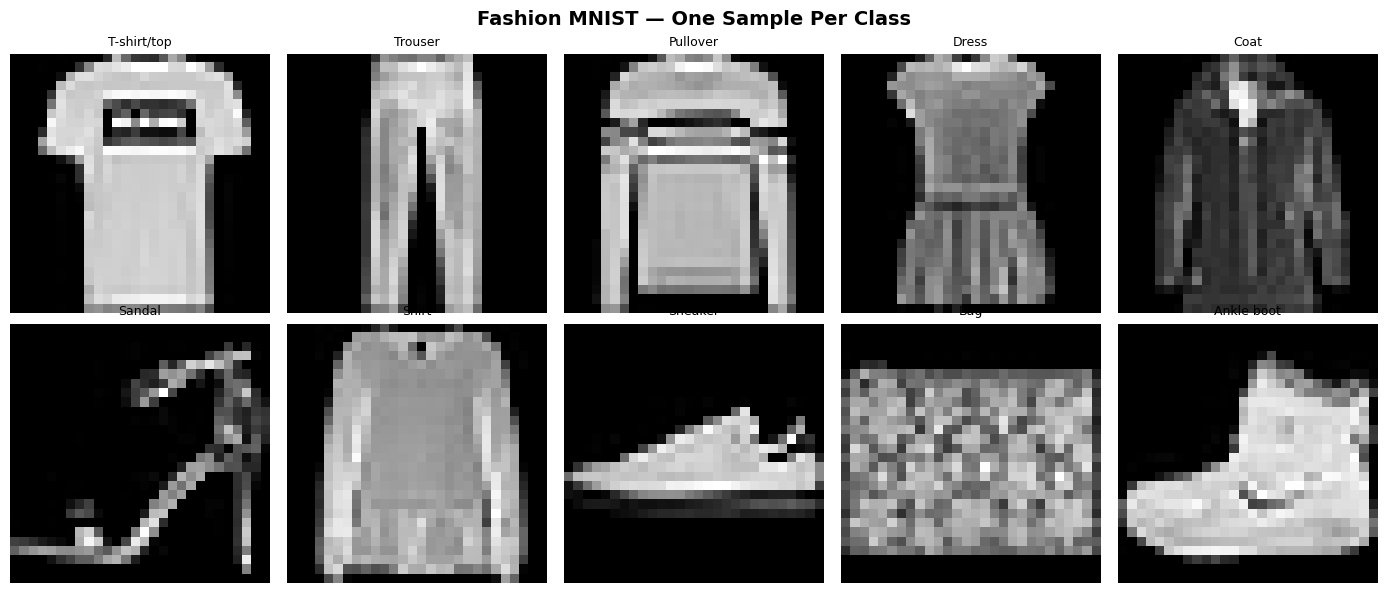

In [3]:
#cell 3 # One sample per class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Fashion MNIST — One Sample Per Class', fontsize=14, fontweight='bold')
for cls_idx, ax in enumerate(axes.flat):
    img_idx = np.where(y_train == cls_idx)[0][0]
    ax.imshow(X_train[img_idx].squeeze(), cmap='gray')
    ax.set_title(CLASS_NAMES[cls_idx], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

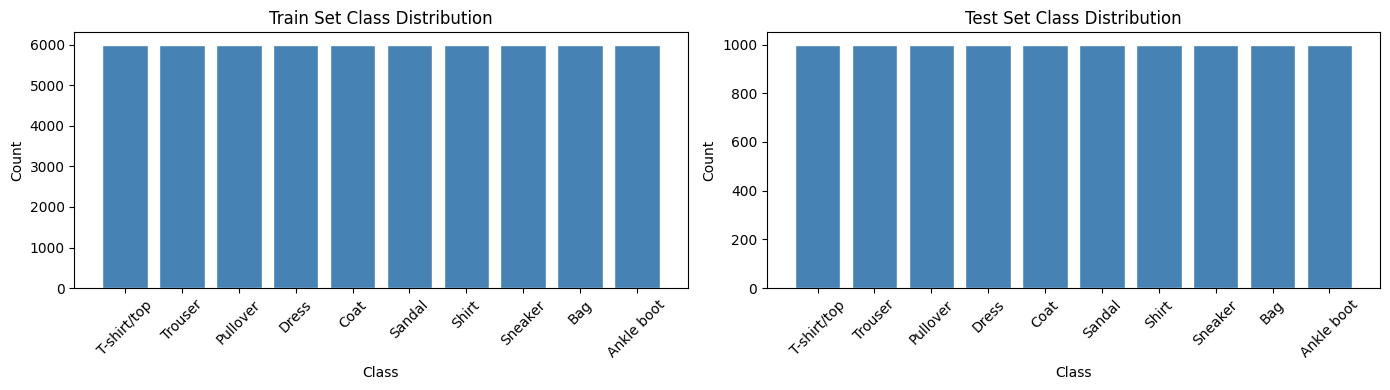

Balanced dataset — 6,000 train / 1,000 test per class.


In [4]:
#cell 4 # Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (labels, title) in zip(axes, [(y_train, 'Train'), (y_test, 'Test')]):
    counts = np.bincount(labels)
    ax.bar(CLASS_NAMES, counts,
           color='steelblue', edgecolor='white')
    ax.set_title(f'{title} Set Class Distribution')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Balanced dataset — 6,000 train / 1,000 test per class.')

In [5]:
#cell 5 # Moderate augmentation for Improved model
augment_v1 = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
], name='augment_v1')


def build_improved_cnn(input_shape=(28, 28, 1), num_classes=10):

    inputs = keras.Input(shape=input_shape, name='input')
    x = augment_v1(inputs)

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)

    # Classifier
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='Improved_CNN')


improved_model = build_improved_cnn()
improved_model.summary()

Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augment_v1 (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 323,370 (1.23 MB)

 Trainable params: 322,474 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)

In [6]:
# cell 6
improved_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb_improved = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=6,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-6, verbose=1),
]

print("Training Improved CNN (up to 10 epochs, Adam, BatchNorm, Dropout, Augmentation)")
improved_history = improved_model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=64,
    callbacks=cb_improved,
    verbose=1
)

improved_loss, improved_acc = improved_model.evaluate(X_test, y_test, verbose=0)
print(f'\nImproved — Test Accuracy: {improved_acc*100:.2f}%')

Training Improved CNN (up to 10 epochs, Adam, BatchNorm, Dropout, Augmentation)
Epoch 1/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.6921 - loss: 0.8325 - val_accuracy: 0.7912 - val_loss: 0.5822 - learning_rate: 0.0010
Epoch 2/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.7985 - loss: 0.5646 - val_accuracy: 0.8443 - val_loss: 0.4356 - learning_rate: 0.0010
Epoch 3/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8220 - loss: 0.4972 - val_accuracy: 0.8609 - val_loss: 0.3907 - learning_rate: 0.0010
Epoch 4/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.8376 - loss: 0.4551 - val_accuracy: 0.8606 - val_loss: 0.3901 - learning_rate: 0.0010
Epoch 5/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8492 - loss: 0.4247 - val_accuracy: 0.8680 - val_loss: 0.3733 - learning_rate: 0.0010
Epoch 6/30
797/797 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.8570 - loss: 0.4047 - val_accuracy: 0.8704 - val_loss: 0.3747 - learning_rate: 0.0

In [18]:
#cell 7 from tensorflow import keras
from tensorflow.keras import layers

def build_tl_model(input_shape=(28,28,3), num_classes=10):

    inputs = keras.Input(shape=input_shape)

    # Resize to match pretrained model
    x = layers.Resizing(224, 224)(inputs)

    # Load pretrained model
    base_model = keras.applications.MobileNetV2(
        input_shape=(224,224,3),
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False  # freeze

    x = base_model(x, training=False)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='TL_MobileNetV2')


tl_model = build_tl_model()
tl_model.summary()

Model: "TL_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
#cell 8
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb  = np.repeat(X_test, 3, axis=-1)

In [9]:
#cell 9
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cb_tl = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=3,
                            restore_best_weights=True, verbose=1)
]

print("Training Transfer Learning Model (MobileNetV2)...")

tl_history = tl_model.fit(
    X_train_rgb, y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=64,
    callbacks=cb_tl,
    verbose=1
)

tl_loss, tl_acc = tl_model.evaluate(X_test_rgb, y_test, verbose=0)

print(f'\nTransfer Learning — Test Accuracy: {tl_acc*100:.2f}%')
print(f'Gain over Improved: +{(tl_acc - improved_acc)*100:.2f}%')

Training Transfer Learning Model (MobileNetV2)...
Epoch 1/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 91s 92ms/step - accuracy: 0.8604 - loss: 0.3858 - val_accuracy: 0.8880 - val_loss: 0.3084
Epoch 2/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.8970 - loss: 0.2793 - val_accuracy: 0.8960 - val_loss: 0.2841
Epoch 3/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9095 - loss: 0.2449 - val_accuracy: 0.8979 - val_loss: 0.2810
Epoch 4/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9202 - loss: 0.2177 - val_accuracy: 0.8988 - val_loss: 0.2919
Epoch 5/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9284 - loss: 0.1969 - val_accuracy: 0.8974 - val_loss: 0.2981
Epoch 6/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9352 - loss: 0.1783 - val_accuracy: 0.8964 - val_loss: 0.3114
Epoch 7/10
797/797 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.9417 - loss: 0.1614 - val_accuracy: 0.8977 - val_loss: 0.3170
Epoch 7: early stopping
Restoring model 

In [10]:
#cell 10
tl_model.save("best_model.keras")

In [11]:
from google.colab import files
files.download("best_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
#cell 11
# Predictions
y_pred_improved = np.argmax(improved_model.predict(X_test, verbose=0), axis=1)
y_pred_tl = np.argmax(tl_model.predict(X_test_rgb, verbose=0), axis=1)

print("Predictions ready")

Predictions ready


In [13]:
#cell 12 Classification Report
print("="*50)
print("Improved CNN — Classification Report")
print("="*50)
print(classification_report(y_test, y_pred_improved, target_names=CLASS_NAMES))

print("\n" + "="*50)
print("Transfer Learning — Classification Report")
print("="*50)
print(classification_report(y_test, y_pred_tl, target_names=CLASS_NAMES))

Improved CNN — Classification Report
              precision    recall  f1-score   support

 T-shirt/top       0.89      0.83      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.90      0.88      0.89      1000
       Dress       0.87      0.95      0.91      1000
        Coat       0.86      0.88      0.87      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.75      0.75      0.75      1000
     Sneaker       0.92      0.99      0.95      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.99      0.93      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000


Transfer Learning — Classification Report
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.84      0.86      1000
     Trouser       1.00      0.97      0.98      100

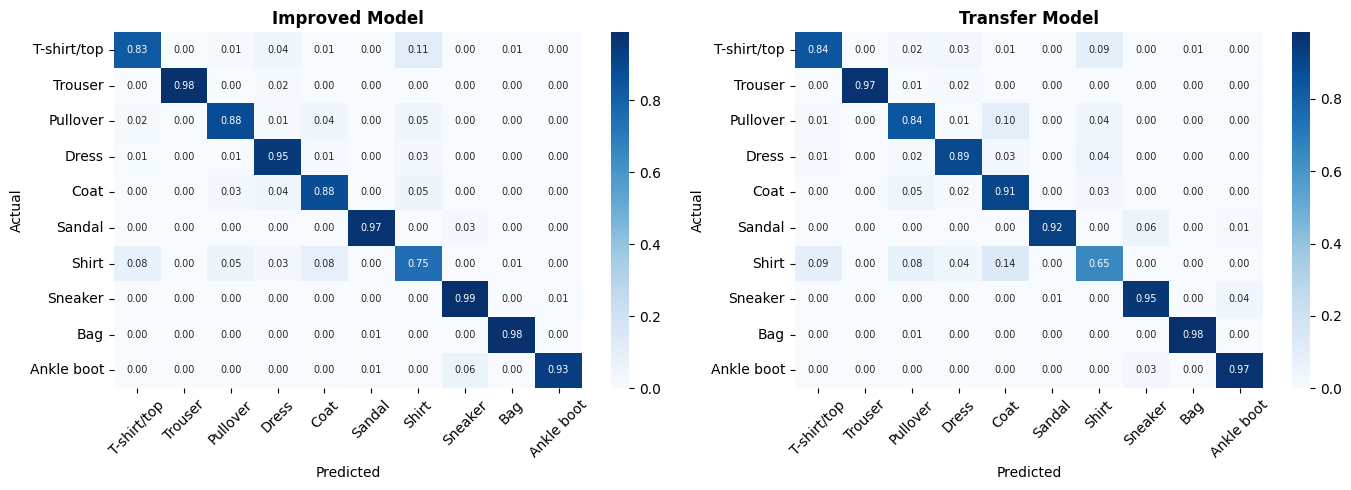

In [14]:
#cell 13 Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, preds) in zip(axes, [
    ('Improved', y_pred_improved),
    ('Transfer', y_pred_tl)
]):

    cm = confusion_matrix(y_test, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, annot_kws={"size":7})

    ax.set_title(f'{name} Model', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

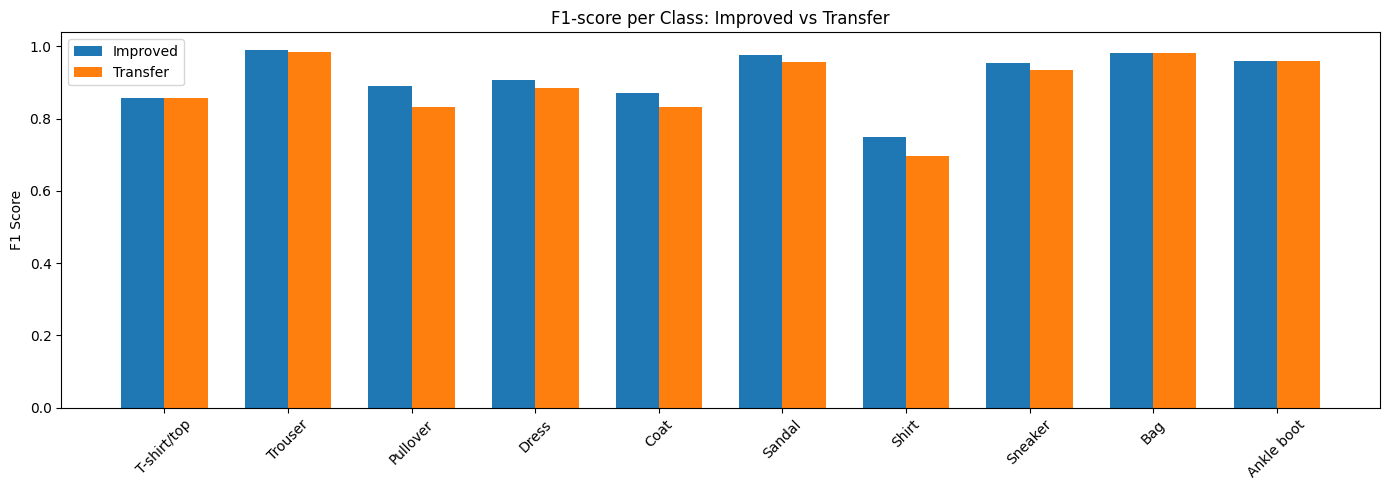

In [15]:
#cell 14 F1-score
from sklearn.metrics import f1_score

f1_improved = f1_score(y_test, y_pred_improved, average=None)
f1_tl = f1_score(y_test, y_pred_tl, average=None)

x = np.arange(len(CLASS_NAMES))
w = 0.35

plt.figure(figsize=(14,5))

plt.bar(x - w/2, f1_improved, w, label='Improved')
plt.bar(x + w/2, f1_tl, w, label='Transfer')

plt.xticks(x, CLASS_NAMES, rotation=45)
plt.ylabel('F1 Score')
plt.title('F1-score per Class: Improved vs Transfer')
plt.legend()

plt.tight_layout()
plt.show()

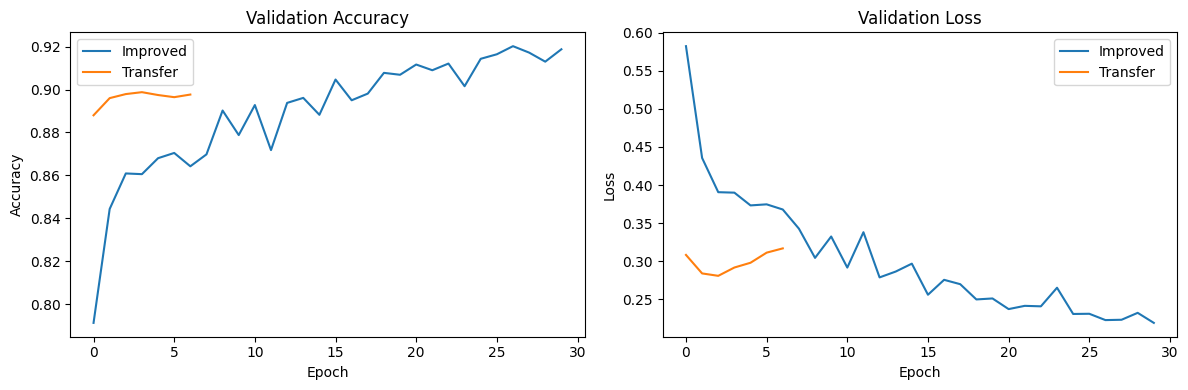

In [16]:
#cell 15 Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(improved_history.history['val_accuracy'], label='Improved')
axes[0].plot(tl_history.history['val_accuracy'], label='Transfer')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(improved_history.history['val_loss'], label='Improved')
axes[1].plot(tl_history.history['val_loss'], label='Transfer')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

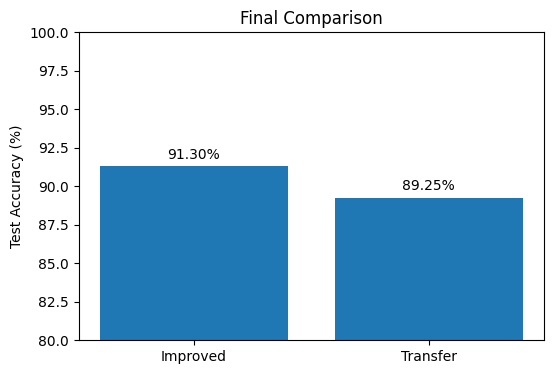

In [17]:
#cell 16
plt.figure(figsize=(6,4))

models = ['Improved', 'Transfer']
accs = [improved_acc*100, tl_acc*100]

plt.bar(models, accs)

plt.ylabel('Test Accuracy (%)')
plt.title('Final Comparison')

for i, v in enumerate(accs):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.ylim(80, 100)
plt.show()